Image Dimensions: (452, 678)


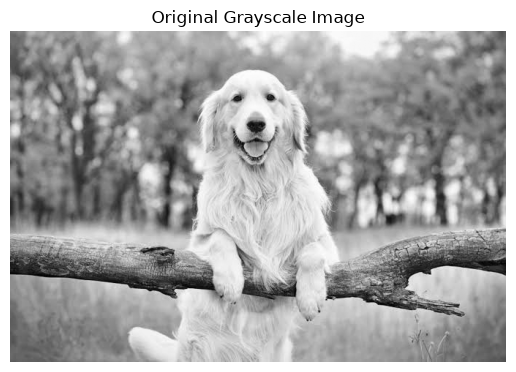

DCT Coefficient Matrix Shape: (452, 678)

First 5x5 DCT Coefficients:
[[ 8.58452077e+04 -2.40399603e+03 -1.21679458e+04  1.03852032e+03
   1.64757700e+03]
 [-5.61803715e+02  5.77904094e+01  6.44325942e+02  2.29751632e+03
   9.95116524e+01]
 [ 1.92583890e+03  1.32222998e+03  4.76042889e+02 -2.60042286e+02
  -3.46605479e+03]
 [ 2.95045739e+03 -1.46136747e+03  5.17680171e+02  1.21323188e+03
  -7.58802133e+02]
 [ 3.55647118e+03 -2.12302247e+03 -2.61217462e+03 -8.04278017e+02
  -1.74277833e+03]]


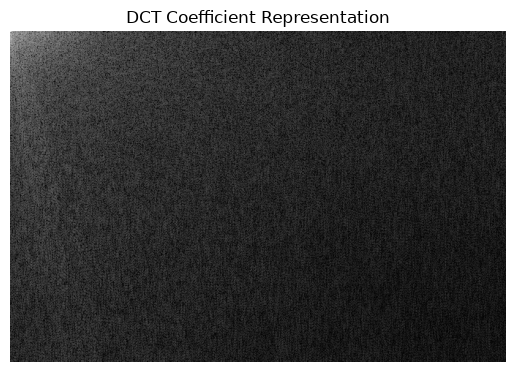

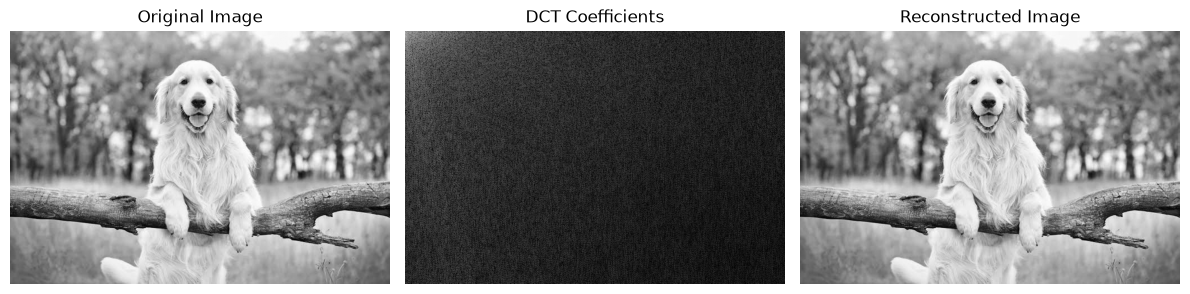

True

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread(
    "../images/dog_grayscale.png",
    cv2.IMREAD_GRAYSCALE
)

print("Image Dimensions:", image.shape)

plt.imshow(image, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()


image_float = image.astype(np.float64)

rows, cols = image.shape

T_row = np.zeros((rows, rows))
T_col = np.zeros((cols, cols))

for u in range(rows):
    for x in range(rows):
        if u == 0:
            alpha = np.sqrt(1 / rows)
        else:
            alpha = np.sqrt(2 / rows)

        T_row[u, x] = (
            alpha *
            np.cos(
                np.pi * (2 * x + 1) * u / (2 * rows)
            )
        )

for v in range(cols):
    for y in range(cols):
        if v == 0:
            alpha = np.sqrt(1 / cols)
        else:
            alpha = np.sqrt(2 / cols)

        T_col[v, y] = (
            alpha *
            np.cos(
                np.pi * (2 * y + 1) * v / (2 * cols)
            )
        )

dct = T_row @ image_float @ T_col.T

print("DCT Coefficient Matrix Shape:", dct.shape)

print("\nFirst 5x5 DCT Coefficients:")
print(dct[:5, :5])


dct_visual = np.log1p(np.abs(dct))

plt.imshow(dct_visual, cmap="gray")
plt.title("DCT Coefficient Representation")
plt.axis("off")
plt.show()


reconstructed = T_row.T @ dct @ T_col

reconstructed = np.clip(
    reconstructed,
    0,
    255
).astype(np.uint8)


plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(dct_visual, cmap="gray")
plt.title("DCT Coefficients")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed Image")
plt.axis("off")

plt.tight_layout()
plt.show()


cv2.imwrite(
    "../images/dog_dct.png",
    np.uint8(
        cv2.normalize(
            dct_visual,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        )
    )
)

cv2.imwrite(
    "../images/dog_dct_reconstructed.png",
    reconstructed
)